In [ ]:
import os
import re
import unicodedata
import numpy as np
import tensorflow as tf
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

In [ ]:
# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


In [ ]:
#  Load dataset
ds = load_dataset("persiannlp/parsinlu_translation_en_fa", revision="refs/convert/parquet")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['source', 'targets', 'category'],
        num_rows: 1621665
    })
    validation: Dataset({
        features: ['source', 'targets', 'category'],
        num_rows: 2137
    })
    test: Dataset({
        features: ['source', 'targets', 'category'],
        num_rows: 48359
    })
})


In [ ]:
# Find EN/FA fields robustly
def guess_fields(dataset_split):
    cols = dataset_split.column_names

    if "translation" in cols:
        sample = dataset_split[0]["translation"]
        if isinstance(sample, dict):
            keys = set(sample.keys())
            en_key = "en" if "en" in keys else ("english" if "english" in keys else None)
            fa_key = "fa" if "fa" in keys else ("persian" if "persian" in keys else ("fa_ir" if "fa_ir" in keys else None))
            if en_key and fa_key:
                return ("translation", en_key), ("translation", fa_key)

    candidates_en = ["en", "english", "source", "src", "src_text", "source_text", "clean_source"]
    candidates_fa = ["fa", "persian", "target", "tgt", "tgt_text", "target_text", "clean_target_1", "clean_target", "targets"]

    en_col = next((c for c in candidates_en if c in cols), None)
    fa_col = next((c for c in candidates_fa if c in cols), None)

    if en_col and fa_col:
        return en_col, fa_col

    raise ValueError(f"Could not infer EN/FA columns from columns={cols}")

en_field, fa_field = guess_fields(ds["train"])
print("EN field:", en_field)
print("FA field:", fa_field)

def get_text(example, field):
    if isinstance(field, tuple):
        col, key = field
        return example[col][key]
    return example[field]


EN field: source
FA field: targets


In [ ]:
# Normalization (NO stopword removal, NO punctuation removal)
DIACRITICS = re.compile(r"[\u064B-\u065F\u0670\u06D6-\u06ED]")

AR2FA_MAP = {"ي":"ی","ك":"ک","ى":"ی","ة":"ه","ـ":""}

def normalize_en(text: str) -> str:
    text = "" if text is None else str(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\u200c", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_fa(text: str) -> str:
    text = "" if text is None else str(text)
    text = unicodedata.normalize("NFKC", text)
    text = DIACRITICS.sub("", text)
    for a, b in AR2FA_MAP.items():
        text = text.replace(a, b)
    text = re.sub(r"[ \t\r\f\v]+", " ", text)
    text = re.sub(r"\s*\n\s*", " ", text).strip()
    return text


In [ ]:
#  Use 20% of train
USE_TRAIN_FRACTION = 0.2
n = int(len(ds["train"]) * USE_TRAIN_FRACTION)
ds["train"] = ds["train"].shuffle(seed=SEED).select(range(n))
print("Using 20% of train:", len(ds["train"]))

Using 20% of train: 324333


In [ ]:
# Train/Val/Test

splits = {
    "train": ds["train"],
    "val": ds["validation"] if "validation" in ds else ds["train"].select(range(1000)),
    "test": ds["test"] if "test" in ds else ds["train"].select(range(1000)),
}
print({k: len(v) for k, v in splits.items()})

{'train': 324333, 'val': 2137, 'test': 48359}


In [ ]:
#  Tokenizer + BERT embedding matrix (mBERT)
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bert_pt = AutoModel.from_pretrained(MODEL_NAME)
pretrained_embed_768 = bert_pt.get_input_embeddings().weight.detach().cpu().numpy()

VOCAB_SIZE = pretrained_embed_768.shape[0]
PAD_ID     = tokenizer.pad_token_id
BOS_ID     = tokenizer.cls_token_id
EOS_ID     = tokenizer.sep_token_id

print("Vocab:", VOCAB_SIZE, "BERT_DIM:", pretrained_embed_768.shape[1],
      "PAD:", PAD_ID, "BOS:", BOS_ID, "EOS:", EOS_ID)


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Vocab: 119547 BERT_DIM: 768 PAD: 0 BOS: 101 EOS: 102


In [ ]:
# Choose MAX_LEN statistically
def estimate_max_len(percentile=95, sample_size=20000, cap=256):
    n = min(len(splits["train"]), sample_size)
    idx = np.random.choice(len(splits["train"]), size=n, replace=False)

    src_lens, tgt_lens = [], []
    for i in idx:
        ex = splits["train"][int(i)]
        en = normalize_en(get_text(ex, en_field))
        fa_raw = get_text(ex, fa_field)
        fa = normalize_fa(fa_raw[0] if isinstance(fa_raw, list) else fa_raw)

        src_ids = tokenizer(en, add_special_tokens=True, truncation=False)["input_ids"]
        tgt_ids = tokenizer(fa, add_special_tokens=True, truncation=False)["input_ids"]
        src_lens.append(len(src_ids))
        tgt_lens.append(len(tgt_ids))

    def round8(x): return int(np.ceil(x / 8) * 8)

    src_p = round8(int(np.percentile(src_lens, percentile)))
    tgt_p = round8(int(np.percentile(tgt_lens, percentile)))

    src_p = int(np.clip(src_p, 16, cap))
    tgt_p = int(np.clip(tgt_p, 16, cap))
    return src_p, tgt_p

MAX_LEN_EN, MAX_LEN_FA = estimate_max_len(percentile=95, sample_size=20000, cap=256)
DEC_LEN = MAX_LEN_FA - 1
print("MAX_LEN_EN =", MAX_LEN_EN, "| MAX_LEN_FA =", MAX_LEN_FA, "| DEC_LEN =", DEC_LEN)


MAX_LEN_EN = 40 | MAX_LEN_FA = 48 | DEC_LEN = 47


In [ ]:
# Choose MAX_LEN statistically
def estimate_max_len(percentile=95, sample_size=20000, cap=256):
    n = min(len(splits["train"]), sample_size)
    idx = np.random.choice(len(splits["train"]), size=n, replace=False)

    src_lens, tgt_lens = [], []
    for i in idx:
        ex = splits["train"][int(i)]
        en = normalize_en(get_text(ex, en_field))
        fa_raw = get_text(ex, fa_field)
        fa = normalize_fa(fa_raw[0] if isinstance(fa_raw, list) else fa_raw)

        src_ids = tokenizer(en, add_special_tokens=True, truncation=False)["input_ids"]
        tgt_ids = tokenizer(fa, add_special_tokens=True, truncation=False)["input_ids"]
        src_lens.append(len(src_ids))
        tgt_lens.append(len(tgt_ids))

    def round8(x): return int(np.ceil(x / 8) * 8)

    src_p = round8(int(np.percentile(src_lens, percentile)))
    tgt_p = round8(int(np.percentile(tgt_lens, percentile)))

    src_p = int(np.clip(src_p, 16, cap))
    tgt_p = int(np.clip(tgt_p, 16, cap))
    return src_p, tgt_p

MAX_LEN_EN, MAX_LEN_FA = estimate_max_len(percentile=95, sample_size=20000, cap=256)
DEC_LEN = MAX_LEN_FA - 1
print("MAX_LEN_EN =", MAX_LEN_EN, "| MAX_LEN_FA =", MAX_LEN_FA, "| DEC_LEN =", DEC_LEN)


MAX_LEN_EN = 40 | MAX_LEN_FA = 48 | DEC_LEN = 47


In [ ]:
# Choose MAX_LEN statistically
def estimate_max_len(percentile=95, sample_size=20000, cap=256):
    n = min(len(splits["train"]), sample_size)
    idx = np.random.choice(len(splits["train"]), size=n, replace=False)

    src_lens, tgt_lens = [], []
    for i in idx:
        ex = splits["train"][int(i)]
        en = normalize_en(get_text(ex, en_field))
        fa_raw = get_text(ex, fa_field)
        fa = normalize_fa(fa_raw[0] if isinstance(fa_raw, list) else fa_raw)

        src_ids = tokenizer(en, add_special_tokens=True, truncation=False)["input_ids"]
        tgt_ids = tokenizer(fa, add_special_tokens=True, truncation=False)["input_ids"]
        src_lens.append(len(src_ids))
        tgt_lens.append(len(tgt_ids))

    def round8(x): return int(np.ceil(x / 8) * 8)

    src_p = round8(int(np.percentile(src_lens, percentile)))
    tgt_p = round8(int(np.percentile(tgt_lens, percentile)))

    src_p = int(np.clip(src_p, 16, cap))
    tgt_p = int(np.clip(tgt_p, 16, cap))
    return src_p, tgt_p

MAX_LEN_EN, MAX_LEN_FA = estimate_max_len(percentile=95, sample_size=20000, cap=256)
DEC_LEN = MAX_LEN_FA - 1
print("MAX_LEN_EN =", MAX_LEN_EN, "| MAX_LEN_FA =", MAX_LEN_FA, "| DEC_LEN =", DEC_LEN)


MAX_LEN_EN = 40 | MAX_LEN_FA = 48 | DEC_LEN = 47


In [ ]:
#  Pre-train check: truncation rate

def truncation_rate(split, n=3000):
    n = min(n, len(split))
    hit_src = hit_tgt = 0
    for i in range(n):
        ex = split[i]
        en = normalize_en(get_text(ex, en_field))
        fa_raw = get_text(ex, fa_field)
        fa = normalize_fa(fa_raw[0] if isinstance(fa_raw, list) else fa_raw)

        src_ids = tokenizer(en, max_length=MAX_LEN_EN, truncation=True, add_special_tokens=True)["input_ids"]
        tgt_ids = tokenizer(fa, max_length=MAX_LEN_FA, truncation=True, add_special_tokens=True)["input_ids"]
        if len(src_ids) >= MAX_LEN_EN: hit_src += 1
        if len(tgt_ids) >= MAX_LEN_FA: hit_tgt += 1

    return hit_src/n, hit_tgt/n

r_src, r_tgt = truncation_rate(splits["train"], n=3000)
print(f"Truncation rate ~ SRC: {r_src*100:.1f}% | TGT: {r_tgt*100:.1f}%")


Truncation rate ~ SRC: 3.0% | TGT: 4.6%


In [ ]:
#  Tokenize (padding fixed)

def preprocess_batch(batch):
    src_texts = [normalize_en(x) for x in batch["__src"]]
    tgt_texts = [normalize_fa(x) for x in batch["__tgt"]]

    enc = tokenizer(
        src_texts,
        max_length=MAX_LEN_EN,
        truncation=True,
        padding="max_length",
        add_special_tokens=True,
    )
    tgt = tokenizer(
        tgt_texts,
        max_length=MAX_LEN_FA,
        truncation=True,
        padding="max_length",
        add_special_tokens=True,
    )

    tgt_ids = tgt["input_ids"]
    decoder_in = [ids[:-1] for ids in tgt_ids]
    labels     = [ids[1:]  for ids in tgt_ids]

    return {"enc_ids": enc["input_ids"], "dec_in": decoder_in, "labels": labels}

def attach_temp_cols(ex):
    fa_raw = get_text(ex, fa_field)
    fa = fa_raw[0] if isinstance(fa_raw, list) else fa_raw
    return {"__src": get_text(ex, en_field), "__tgt": fa}

for k in splits:
    splits[k] = splits[k].map(attach_temp_cols, desc=f"Attach src/tgt ({k})")
    splits[k] = splits[k].map(
        preprocess_batch, batched=True, remove_columns=splits[k].column_names,
        desc=f"Tokenize ({k})"
    )

Attach src/tgt (train):   0%|          | 0/324333 [00:00<?, ? examples/s]

Tokenize (train):   0%|          | 0/324333 [00:00<?, ? examples/s]

Attach src/tgt (val):   0%|          | 0/2137 [00:00<?, ? examples/s]

Tokenize (val):   0%|          | 0/2137 [00:00<?, ? examples/s]

Attach src/tgt (test):   0%|          | 0/48359 [00:00<?, ? examples/s]

Tokenize (test):   0%|          | 0/48359 [00:00<?, ? examples/s]

In [ ]:
# =========================================================
# 9) Build tf.data  (FIXED Column->np.array)
# =========================================================
BATCH_SIZE = 64

def to_tf_dataset(hf_ds, shuffle=False):
    enc_ids = np.array(hf_ds["enc_ids"], dtype=np.int32)
    dec_in  = np.array(hf_ds["dec_in"],  dtype=np.int32)
    labels  = np.array(hf_ds["labels"],  dtype=np.int32)

    x = {"enc_ids": enc_ids, "dec_in": dec_in}
    y = labels

    tfds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        tfds = tfds.shuffle(min(20000, len(hf_ds)), seed=SEED, reshuffle_each_iteration=True)
    tfds = tfds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return tfds

train_ds = to_tf_dataset(splits["train"], shuffle=True)
val_ds   = to_tf_dataset(splits["val"], shuffle=False)
test_ds  = to_tf_dataset(splits["test"], shuffle=False)


In [ ]:
# =========================================================
# ✅ (NEW) Pre-train check: shift correctness
# =========================================================
x0, y0 = next(iter(train_ds.take(1)))
dec0 = x0["dec_in"].numpy()
lab0 = y0.numpy()
shift_ratio = np.mean(dec0[0, 1:] == lab0[0, :-1])
print("Shift match ratio (sample0):", shift_ratio)
print("PAD% in labels:", np.mean(lab0 == PAD_ID))


Shift match ratio (sample0): 1.0
PAD% in labels: 0.5648271276595744


In [ ]:
import keras
from keras import ops

D_MODEL = 300  # ✅ مطابق تکلیف

class TokenPosEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, max_len, d_model, pretrained_matrix_768_shape,  # Changed to shape
                 dropout=0.2, trainable_embed=False, name=None, **kwargs):
        super().__init__(name=name, **kwargs)

        # We store the shape and re-initialize the embedding with a dummy one
        # Then, set the weights explicitly in build()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.d_model = d_model
        self.pretrained_matrix_768_shape = pretrained_matrix_768_shape
        self.dropout_rate = dropout
        self.trainable_embed = trainable_embed

        self.tok_emb_768 = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=pretrained_matrix_768_shape[1],  # Use stored shape
            embeddings_initializer="zeros", # Initialize with zeros, weights will be set in build
            trainable=trainable_embed,
            name="token_emb_bert_init",
        )
        self.proj = tf.keras.layers.Dense(d_model, use_bias=False, name="proj_768_to_300")

        self.pos_emb = tf.keras.layers.Embedding(input_dim=max_len, output_dim=d_model, name="pos_embedding")
        self.drop = tf.keras.layers.Dropout(dropout)

    # Keras calls this method automatically on first call with input shapes
    def build(self, input_shape):
        # Assign the pretrained weights here. They are not part of the config.
        # This assumes pretrained_embed_768 is available in the global scope
        # or passed via `custom_objects` when loading.
        self.tok_emb_768.build(input_shape)
        self.tok_emb_768.set_weights([pretrained_embed_768])
        super().build(input_shape)

    def call(self, x, training=False):
        L = ops.shape(x)[1]
        positions = ops.arange(0, L, 1)
        pos = self.pos_emb(positions)       # (L, d_model)
        tok = self.tok_emb_768(x)           # (B, L, 768)
        tok = self.proj(tok)                # (B, L, 300)
        out = tok + pos
        return self.drop(out, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            "vocab_size": self.vocab_size,
            "max_len": self.max_len,
            "d_model": self.d_model,
            "pretrained_matrix_768_shape": self.pretrained_matrix_768_shape, # Store shape only
            "dropout": self.dropout_rate,
            "trainable_embed": self.trainable_embed,
            "name": self.name
        })
        return config

    # @classmethod
    # def from_config(cls, config):
    #     # When loading, we cannot pass pretrained_matrix_768 directly.
    #     # A placeholder will be used, and the weights need to be set externally after loading
    #     return cls(**config)


class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.2, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.dropout_rate = dropout
        self.mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
        )
        self.ffn1 = tf.keras.layers.Dense(dff, activation="relu")
        self.ffn2 = tf.keras.layers.Dense(d_model)
        self.drop = tf.keras.layers.Dropout(dropout)
        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, attn_mask, training=False):
        a = self.mha(x, x, attention_mask=attn_mask, training=training)
        x = self.norm1(x + a)
        f = self.ffn1(x)
        f = self.drop(f, training=training)
        f = self.ffn2(f)
        x = self.norm2(x + f)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "dff": self.dff,
            "dropout": self.dropout_rate,
            "name": self.name
        })
        return config


class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.2, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.dff = dff
        self.dropout_rate = dropout

        self.self_mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
        )
        self.cross_mha = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout
        )
        self.ffn1 = tf.keras.layers.Dense(dff, activation="relu")
        self.ffn2 = tf.keras.layers.Dense(d_model)
        self.drop = tf.keras.layers.Dropout(dropout)

        self.norm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, enc_out, self_mask, cross_mask, training=False):
        a1 = self.self_mha(
            x, x,
            attention_mask=self_mask,
            use_causal_mask=True,
            training=training
        )
        x = self.norm1(x + a1)

        a2 = self.cross_mha(
            x, enc_out,
            attention_mask=cross_mask,
            training=training
        )
        x = self.norm2(x + a2)

        f = self.ffn1(x)
        f = self.drop(f, training=training)
        f = self.ffn2(f)
        x = self.norm3(x + f)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "num_heads": self.num_heads,
            "dff": self.dff,
            "dropout": self.dropout_rate,
            "name": self.name
        })
        return config

def make_padding_mask(ids, pad_id):
    return ops.not_equal(ids, pad_id)  # (B,L) bool

def expand_keymask_to_attn(key_mask, query_len):
    km = ops.expand_dims(key_mask, axis=1)      # (B,1,K)
    return ops.tile(km, (1, query_len, 1))      # (B,Q,K)

def build_transformer_seq2seq(
    vocab_size,
    d_model,
    max_len_enc,
    max_len_dec,
    pretrained_matrix_768, # Still passed here for initial construction
    pad_id,
    num_layers=2,
    num_heads=6,
    dff=1024,
    dropout=0.2,
    trainable_embed=False,
):
    enc_ids_in = tf.keras.Input(shape=(max_len_enc,), dtype=tf.int32, name="enc_ids")
    dec_ids_in = tf.keras.Input(shape=(max_len_dec,), dtype=tf.int32, name="dec_in")

    # Pass the shape to the TokenPosEmbedding constructor
    enc_embed = TokenPosEmbedding(vocab_size, max_len_enc, d_model, pretrained_matrix_768.shape,
                                  dropout=dropout, trainable_embed=trainable_embed, name="enc_emb")
    dec_embed = TokenPosEmbedding(vocab_size, max_len_dec, d_model, pretrained_matrix_768.shape,
                                  dropout=dropout, trainable_embed=trainable_embed, name="dec_emb")

    enc_x = enc_embed(enc_ids_in)
    dec_x = dec_embed(dec_ids_in)

    enc_keymask = make_padding_mask(enc_ids_in, pad_id)   # (B,S)
    dec_keymask = make_padding_mask(dec_ids_in, pad_id)   # (B,T)

    enc_self_mask = expand_keymask_to_attn(enc_keymask, max_len_enc)  # (B,S,S)
    dec_self_mask = expand_keymask_to_attn(dec_keymask, max_len_dec)  # (B,T,T)
    cross_mask    = expand_keymask_to_attn(enc_keymask, max_len_dec)  # (B,T,S)

    for i in range(num_layers):
        enc_x = TransformerEncoderLayer(d_model, num_heads, dff, dropout, name=f"enc_{i}")(enc_x, enc_self_mask)

    for i in range(num_layers):
        dec_x = TransformerDecoderLayer(d_model, num_heads, dff, dropout, name=f"dec_{i}")(
            dec_x, enc_x, dec_self_mask, cross_mask
        )

    logits = tf.keras.layers.Dense(vocab_size, dtype="float32", name="logits")(dec_x)
    return tf.keras.Model({"enc_ids": enc_ids_in, "dec_in": dec_ids_in}, logits, name="BERTInitTransformer_d300")

model = build_transformer_seq2seq(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    max_len_enc=MAX_LEN_EN,
    max_len_dec=DEC_LEN,
    pretrained_matrix_768=pretrained_embed_768,
    pad_id=PAD_ID,
    num_layers=2,
    num_heads=6,
    dff=1024,
    dropout=0.2,
    trainable_embed=False
)

model.summary()

Model: "BERTInitTransformer_d300"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_ids             │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 40)        │          0 │ enc_ids[0][0]     │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_in (InputLayer) │ (None, 47)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_3       │ (None, 1, 40)     │          0 │ not_equal_2[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_emb             │ (None, 40, 300)   │ 92,054,496 │ enc_ids[0][0]     │
│ (TokenPosEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tile_3 (Tile)       │ (None, 40, 40)    │          0 │ expand_dims_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 47)        │          0 │ dec_in[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_0               │ (None, 40, 300)   │    978,124 │ enc_emb[0][0],    │
│ (TransformerEncode… │                   │            │ tile_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_4       │ (None, 1, 47)     │          0 │ not_equal_3[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_5       │ (None, 1, 40)     │          0 │ not_equal_2[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_emb             │ (None, 47, 300)   │ 92,056,596 │ dec_in[0][0]      │
│ (TokenPosEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_1               │ (None, 40, 300)   │    978,124 │ enc_0[0][0],      │
│ (TransformerEncode… │                   │            │ tile_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tile_4 (Tile)       │ (None, 47, 47)    │          0 │ expand_dims_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tile_5 (Tile)       │ (None, 47, 40)    │          0 │ expand_dims_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_0               │ (None, 47, 300)   │  1,339,924 │ dec_emb[0][0],    │
│ (TransformerDecode… │                   │            │ enc_1[0][0],      │
│                     │                   │            │ tile_4[0][0],     │
│                     │                   │            │ tile_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_1               │ (None, 47, 300)   │  1,339,924 │ dec_0[0][0],      │
│ (TransformerDecode… │                   │            │ enc_1[0][0],      │
│                     │                   │            │ tile_4[0][0],     │
│                     │                   │            │ tile_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 47,        │ 35,983,647 │ dec_1[0][0]     

 Total params: 224,730,835 (857.28 MB)

 Trainable params: 41,106,643 (156.81 MB)

 Non-trainable params: 183,624,192 (700.47 MB)

In [ ]:
# =========================================================
# 11) ✅ Better loss: Masked Sparse Label Smoothing (no one-hot)
# =========================================================
LABEL_SMOOTH = 0.1

def masked_ls_loss(y_true, y_pred):
    # y_true: (B,T), y_pred logits: (B,T,V)
    y_true = tf.cast(y_true, tf.int32)

    log_probs = tf.nn.log_softmax(y_pred, axis=-1)  # (B,T,V)

    # NLL for correct class
    nll = -tf.gather(log_probs, y_true[..., None], batch_dims=2)  # (B,T,1)
    nll = tf.squeeze(nll, axis=-1)  # (B,T)

    # smoothed loss = mean negative log-prob over vocab
    smooth = -tf.reduce_mean(log_probs, axis=-1)  # (B,T)

    loss = (1.0 - LABEL_SMOOTH) * nll + LABEL_SMOOTH * smooth

    mask = tf.cast(tf.not_equal(y_true, PAD_ID), tf.float32)
    loss = loss * mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-9)

def masked_accuracy(y_true, y_pred):
    y_hat = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
    match = tf.cast(tf.equal(tf.cast(y_true, tf.int32), y_hat), tf.float32)
    mask = tf.cast(tf.not_equal(tf.cast(y_true, tf.int32), PAD_ID), tf.float32)
    match = match * mask
    return tf.reduce_sum(match) / (tf.reduce_sum(mask) + 1e-9)

In [ ]:
# =========================================================
# 12) ✅ Better optimizer: Transformer warmup schedule + clipnorm
# =========================================================
class TransformerSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=2000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32) + 1.0
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step),
            step * tf.math.pow(self.warmup, -1.5)
        )

    def get_config(self):
        return {
            "d_model": self.d_model.numpy(), # Convert Tensor to numpy for serialization
            "warmup_steps": self.warmup.numpy()
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

lr_schedule = TransformerSchedule(D_MODEL, warmup_steps=2000)

opt = tf.keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9, beta_2=0.98, epsilon=1e-9,
    clipnorm=1.0
)

model.compile(optimizer=opt, loss=masked_ls_loss, metrics=[masked_accuracy])

In [ ]:
# =========================================================
# ✅ (OPTIONAL) Sanity Overfit Test (برای اطمینان از درست بودن pipeline)
# =========================================================
DO_SANITY_OVERFIT = False
if DO_SANITY_OVERFIT:
    small = splits["train"].select(range(256))
    small_ds = to_tf_dataset(small, shuffle=True)
    model.fit(small_ds, epochs=20)

In [26]:
# =========================================================
# 13) Train
# =========================================================
EPOCHS = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True,
                                      monitor="val_masked_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True,
                                     monitor="val_masked_accuracy", mode="max"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 376s 66ms/step - loss: 4.5199 - masked_accuracy: 0.3433 - val_loss: 4.5884 - val_masked_accuracy: 0.3552
Epoch 2/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 300s 59ms/step - loss: 4.3347 - masked_accuracy: 0.3736 - val_loss: 4.3828 - val_masked_accuracy: 0.3918
Epoch 3/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 299s 59ms/step - loss: 4.1897 - masked_accuracy: 0.3980 - val_loss: 4.2809 - val_masked_accuracy: 0.4068
Epoch 4/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 299s 59ms/step - loss: 4.1082 - masked_accuracy: 0.4117 - val_loss: 4.2126 - val_masked_accuracy: 0.4193
Epoch 5/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 299s 59ms/step - loss: 4.0518 - masked_accuracy: 0.4215 - val_loss: 4.1607 - val_masked_accuracy: 0.4302
Epoch 6/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 298s 59ms/step - loss: 4.0101 - masked_accuracy: 0.4288 - val_loss: 4.1233 - val_masked_accuracy: 0.4373
Epoch 7/10
5068/5068 ━━━━━━━━━━━━━━━━━━━━ 295s 58ms/step - loss: 3.9775 - masked_accuracy: 0.4344 - val_loss: 4.0828 -

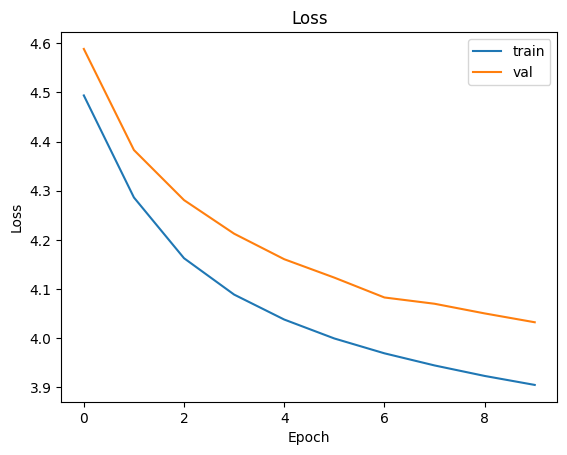

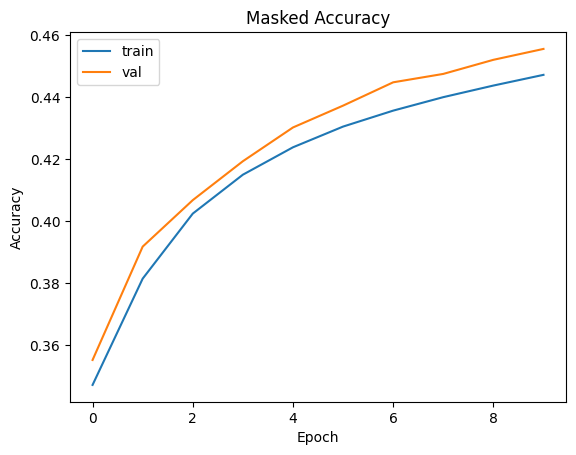

In [27]:
import matplotlib.pyplot as plt

def plot_history(history):
    hist = history.history
    keys = list(hist.keys())

    # Loss
    if "loss" in hist:
        plt.figure()
        plt.plot(hist["loss"])
        if "val_loss" in hist:
            plt.plot(hist["val_loss"])
            plt.title("Loss")
            plt.legend(["train", "val"])
        else:
            plt.title("Train Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    # Accuracy (masked)
    acc_key = None
    for k in keys:
        if "masked_accuracy" in k and not k.startswith("val_"):
            acc_key = k
            break
    if acc_key:
        plt.figure()
        plt.plot(hist[acc_key])
        val_key = "val_" + acc_key
        if val_key in hist:
            plt.plot(hist[val_key])
            plt.title("Masked Accuracy")
            plt.legend(["train", "val"])
        else:
            plt.title("Train Masked Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.show()

plot_history(history)


In [33]:
best_model = tf.keras.models.load_model(
    "best_model.keras",
    custom_objects={
        # custom layers
        "TokenPosEmbedding": TokenPosEmbedding,
        "TransformerEncoderLayer": TransformerEncoderLayer,
        "TransformerDecoderLayer": TransformerDecoderLayer,

        "masked_ls_loss": masked_ls_loss,
        "masked_accuracy": masked_accuracy,
        "TransformerSchedule": TransformerSchedule,
    },
    compile=False 
)

print("✅ Best model loaded (compile=False).")
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4, clipnorm=1.0),
    loss=masked_ls_loss,
    metrics=[masked_accuracy]
)
print("✅ Best model compiled.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'enc_0', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'enc_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'dec_0', however the layer does not have a `build()` m

✅ Best model loaded (compile=False).
✅ Best model compiled.


In [34]:
def encode_src_text(src_text: str):
    enc = tokenizer(
        normalize_en(src_text),
        max_length=MAX_LEN_EN,
        truncation=True,
        padding="max_length",
        add_special_tokens=True,
        return_tensors="np",
    )
    return tf.constant(enc["input_ids"].astype(np.int32))  # (1, S)

def beam_search_translate(model, src_text, beam_size=4, max_len=None, length_penalty=0.7):

    if max_len is None:
        max_len = DEC_LEN

    enc_ids = encode_src_text(src_text)  # (1,S)

    beams = [([BOS_ID], 0.0)]
    finished = []

    for t in range(max_len):
        new_beams = []

        for tokens, score in beams:
            if tokens[-1] == EOS_ID:
                finished.append((tokens, score))
                continue

            dec_in = tokens + [PAD_ID] * (DEC_LEN - len(tokens))
            dec_in = tf.constant(np.array(dec_in, dtype=np.int32)[None, :])  # (1,T)

            logits = model({"enc_ids": enc_ids, "dec_in": dec_in}, training=False)  # (1,T,V)
            step_logits = logits[0, len(tokens)-1, :]  
            log_probs = tf.nn.log_softmax(step_logits).numpy()

            topk = np.argpartition(-log_probs, beam_size)[:beam_size]
            topk = topk[np.argsort(-log_probs[topk])]

            for tok_id in topk:
                new_tokens = tokens + [int(tok_id)]
                new_score = score + float(log_probs[tok_id])
                new_beams.append((new_tokens, new_score))

        def lp(tokens, score):
            L = max(1, len(tokens))
            return score / (L ** length_penalty)

        new_beams.sort(key=lambda x: lp(x[0], x[1]), reverse=True)
        beams = new_beams[:beam_size]

        if len(finished) >= beam_size:
            break

    candidates = finished if finished else beams
    candidates.sort(key=lambda x: x[1] / (max(1, len(x[0])) ** length_penalty), reverse=True)

    best_tokens = candidates[0][0]
    pred_text = tokenizer.decode(best_tokens, skip_special_tokens=True)
    return pred_text


In [35]:
def get_raw_pair(example):
    src = get_text(example, en_field)
    tgt_raw = get_text(example, fa_field)
    if isinstance(tgt_raw, list):
        tgt_raw = tgt_raw[0]
    return normalize_en(src), normalize_fa(tgt_raw)

def sample_raw_pairs(split_ds, n=500, seed=42):
    n = min(n, len(split_ds))
    idx = np.random.RandomState(seed).choice(len(split_ds), size=n, replace=False)
    srcs, refs = [], []
    for i in idx:
        s, r = get_raw_pair(split_ds[int(i)])
        srcs.append(s)
        refs.append(r)
    return srcs, refs


In [37]:
!pip -q install sacrebleu rouge-score bert-score

In [38]:
from sacrebleu import corpus_bleu
from rouge_score import rouge_scorer
from bert_score import score as bertscore

In [39]:
rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)

In [40]:
def evaluate_translation(model, split_raw, n_eval=200, beam_size=4):
    srcs, refs = sample_raw_pairs(split_raw, n=n_eval, seed=SEED)

    preds = []
    for i, s in enumerate(srcs):
        pred = beam_search_translate(model, s, beam_size=beam_size)
        preds.append(pred)

        if (i+1) % 25 == 0:
            print(f"Decoded {i+1}/{len(srcs)}")

    # BLEU
    bleu = corpus_bleu(preds, [refs]).score

    # ROUGE
    r1, r2, rL = [], [], []
    for ref, pred in zip(refs, preds):
        sc = rouge.score(ref, pred)
        r1.append(sc["rouge1"].fmeasure)
        r2.append(sc["rouge2"].fmeasure)
        rL.append(sc["rougeL"].fmeasure)

    rouge_scores = {
        "rouge1": float(np.mean(r1)),
        "rouge2": float(np.mean(r2)),
        "rougeL": float(np.mean(rL)),
    }

    P, R, F1 = bertscore(
        preds, refs,
        lang="fa",
        model_type="HooshvareLab/bert-base-parsbert-uncased",
        verbose=False
    )
    bert_f1 = float(F1.mean().item())

    return bleu, rouge_scores, bert_f1, srcs, refs, preds

In [43]:
def evaluate_translation(model, split_raw, n_eval=100, beam_size=2):
    srcs, refs = sample_raw_pairs(split_raw, n=n_eval, seed=SEED)

    preds = []
    for i, s in enumerate(srcs):
        pred = beam_search_translate(model, s, beam_size=beam_size)
        preds.append(pred)

        if (i+1) % 25 == 0:
            print(f"Decoded {i+1}/{len(srcs)}")

    # BLEU
    bleu = corpus_bleu(preds, [refs]).score

    # ROUGE
    r1, r2, rL = [], [], []
    for ref, pred in zip(refs, preds):
        sc = rouge.score(ref, pred)
        r1.append(sc["rouge1"].fmeasure)
        r2.append(sc["rouge2"].fmeasure)
        rL.append(sc["rougeL"].fmeasure)

    rouge_scores = {
        "rouge1": float(np.mean(r1)),
        "rouge2": float(np.mean(r2)),
        "rougeL": float(np.mean(rL)),
    }

    P, R, F1 = bertscore(
        preds, refs,
        lang="fa",
        model_type="HooshvareLab/bert-base-parsbert-uncased",
        num_layers=12, 
        verbose=False
    )
    bert_f1 = float(F1.mean().item())

    return bleu, rouge_scores, bert_f1, srcs, refs, preds

bleu, rouge_scores, bert_f1, srcs, refs, preds = evaluate_translation(
    best_model, ds["test"], n_eval=100, beam_size=2
)


Decoded 25/100
Decoded 50/100
Decoded 75/100
Decoded 100/100


config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

In [44]:


print("\n==============================")
print("✅ Final Evaluation (TEST subset)")
print(f"BLEU: {bleu:.2f}")
print("ROUGE:", rouge_scores)
print(f"BERTScore(F1): {bert_f1:.4f}")
print("==============================")



✅ Final Evaluation (TEST subset)
BLEU: 0.70
ROUGE: {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
BERTScore(F1): 0.4671


In [45]:
for i in range(8):
    print("\n--------------------------")
    print("EN :", srcs[i])
    print("REF:", refs[i])
    print("PRD:", preds[i])



--------------------------
EN : He knows what (appears to His creatures as) before or after or behind them: but they shall not compass it with their knowledge.
REF: [خدا] آنچه را [از احوال و اعمال بندگان] پیش روی آنهاست و آنچه را [از ثواب و کیفر] در آینده دارند، می‌داند و آنان از جهت دانش به او احاطه ندارند،
PRD: او میداند که در برابر موجودات او چه موجودی دارد و یا پس از پشت سرشان ، اما آنها با دانششان نمیتوانند با آن آگاه شوند.

--------------------------
EN : yet something in his honest eyes made her blush and wish she had her old dress on.
REF: چیزی در چشمان نجیب لاری بود که باعث گردید دختر احساس کند که تا بناگوشش سرخ شده است و آرزو کرد که کاش همان لباس کهنه‌ی خودش را پوشیده بود.
PRD: با این حال چیزی در چشمان شرافتمندانه و آرزو میکرد که پیراهنش را روی لباس پوشیده بود.

--------------------------
EN : And not holding the Head, from which all the body by joints and bands having nourishment ministered, and knit together, increaseth with the increase of God.
REF: زانرو که‌ای برادران مح

In [ ]:
for i in range(8):
    print("\n--------------------------")
    print("EN :", srcs[i])
    print("REF:", refs[i])
    print("PRD:", preds[i])



--------------------------
EN : He knows what (appears to His creatures as) before or after or behind them: but they shall not compass it with their knowledge.
REF: [خدا] آنچه را [از احوال و اعمال بندگان] پیش روی آنهاست و آنچه را [از ثواب و کیفر] در آینده دارند، می‌داند و آنان از جهت دانش به او احاطه ندارند،
PRD: او میداند که در برابر موجودات او چه موجودی دارد و یا پس از پشت سرشان ، اما آنها با دانششان نمیتوانند با آن آگاه شوند.

--------------------------
EN : yet something in his honest eyes made her blush and wish she had her old dress on.
REF: چیزی در چشمان نجیب لاری بود که باعث گردید دختر احساس کند که تا بناگوشش سرخ شده است و آرزو کرد که کاش همان لباس کهنه‌ی خودش را پوشیده بود.
PRD: با این حال چیزی در چشمان شرافتمندانه و آرزو میکرد که پیراهنش را روی لباس پوشیده بود.

--------------------------
EN : And not holding the Head, from which all the body by joints and bands having nourishment ministered, and knit together, increaseth with the increase of God.
REF: زانرو که‌ای برادران مح

In [46]:
import numpy as np
import re
from sacrebleu import corpus_bleu
from rouge_score import rouge_scorer
from bert_score import score as bertscore

SEED = 42

AR2FA_MAP = {"ي":"ی","ك":"ک","ة":"ه","ؤ":"و","إ":"ا","أ":"ا","ٱ":"ا","ـ":""}
FA_PUNC = r'([؟،؛!.?,;:"\'()\[\]{}<>/\\\-–—])'
EN_PUNC = r'([?.!,;:"\'()\[\]{}<>/\\\-–—])'

def normalize_en(s):
    s = "" if s is None else str(s)
    s = re.sub(EN_PUNC, r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def normalize_fa(s):
    s = "" if s is None else str(s)
    for a,b in AR2FA_MAP.items():
        s = s.replace(a,b)
    s = s.replace("\\u200c", "\u200c")
    s = re.sub(FA_PUNC, r" \1 ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

_persian_re = re.compile(r"[\u0600-\u06FF]")
_latin_re   = re.compile(r"[A-Za-z]")

def looks_persian(s: str) -> bool:
    s = "" if s is None else str(s)
    return len(_persian_re.findall(s)) > len(_latin_re.findall(s))

def pick_best_target(targets):
    if not targets:
        return ""
    for t in targets:
        if isinstance(t, str) and t.strip() and looks_persian(t):
            return t
    for t in targets:
        if isinstance(t, str) and t.strip():
            return t
    return ""



In [47]:
def encode_src_text(src_text: str):
    enc = tokenizer(
        normalize_en(src_text),
        max_length=MAX_LEN_EN,
        truncation=True,
        padding="max_length",
        add_special_tokens=True,
        return_tensors="np",
    )
    return tf.constant(enc["input_ids"].astype(np.int32))  # (1,S)




In [48]:

def beam_search_translate(model, src_text, beam_size=4, max_len_dec=None, length_penalty=0.7):
    if max_len_dec is None:
        max_len_dec = DEC_LEN  

    enc_ids = encode_src_text(src_text)

    beams = [([BOS_ID], 0.0)]
    finished = []

    for _ in range(max_len_dec):
        new_beams = []

        for tokens, score in beams:
            if tokens[-1] == EOS_ID:
                finished.append((tokens, score))
                continue

            dec_in = tokens + [PAD_ID] * (max_len_dec - len(tokens))
            dec_in = tf.constant(np.array(dec_in, dtype=np.int32)[None, :])

            logits = model({"enc_ids": enc_ids, "dec_in": dec_in}, training=False)
            step_logits = logits[0, len(tokens)-1, :]
            log_probs = tf.nn.log_softmax(step_logits).numpy()

            k = min(beam_size, log_probs.shape[0])
            topk = np.argpartition(-log_probs, k)[:k]
            topk = topk[np.argsort(-log_probs[topk])]

            for tok_id in topk:
                tok_id = int(tok_id)
                new_tokens = tokens + [tok_id]
                new_score = score + float(log_probs[tok_id])
                new_beams.append((new_tokens, new_score))

        def norm_score(tokens, score):
            L = max(1, len(tokens))
            return score / (L ** length_penalty)

        new_beams.sort(key=lambda x: norm_score(x[0], x[1]), reverse=True)
        beams = new_beams[:beam_size]

        if len(finished) >= beam_size:
            break

    candidates = finished if finished else beams
    candidates.sort(key=lambda x: x[1] / (max(1, len(x[0])) ** length_penalty), reverse=True)

    best_tokens = candidates[0][0]
    return tokenizer.decode(best_tokens, skip_special_tokens=True).strip()

In [49]:
def sample_raw_pairs(split_ds, n=200, seed=42):
    n = min(n, len(split_ds))
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(split_ds), size=n, replace=False)

    srcs, refs = [], []
    for i in idx:
        ex = split_ds[int(i)]
        src = normalize_en(ex["source"])
        ref = normalize_fa(pick_best_target(ex["targets"]))
        if src.strip() and ref.strip():
            srcs.append(src)
            refs.append(ref)
    return srcs, refs

rouge = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=False)


In [50]:

def evaluate_translation(model, split_raw, n_eval=100, beam_size=2):
    srcs, refs = sample_raw_pairs(split_raw, n=n_eval, seed=SEED)

    preds = []
    for i, s in enumerate(srcs):
        preds.append(beam_search_translate(model, s, beam_size=beam_size))
        if (i+1) % 25 == 0:
            print(f"Decoded {i+1}/{len(srcs)}")

    # BLEU
    bleu = corpus_bleu(preds, [refs]).score

    # ROUGE
    r1, r2, rL = [], [], []
    for ref, pred in zip(refs, preds):
        sc = rouge.score(ref, pred)
        r1.append(sc["rouge1"].fmeasure)
        r2.append(sc["rouge2"].fmeasure)
        rL.append(sc["rougeL"].fmeasure)

    rouge_scores = {"rouge1": float(np.mean(r1)), "rouge2": float(np.mean(r2)), "rougeL": float(np.mean(rL))}

    P, R, F1 = bertscore(
        preds, refs,
        lang="fa",
        model_type="HooshvareLab/bert-base-parsbert-uncased",
        verbose=False
    )
    bert_f1 = float(F1.mean().item())

    return bleu, rouge_scores, bert_f1, srcs, refs, preds

In [52]:
print(ds)


DatasetDict({
    train: Dataset({
        features: ['source', 'targets', 'category'],
        num_rows: 324333
    })
    validation: Dataset({
        features: ['source', 'targets', 'category'],
        num_rows: 2137
    })
    test: Dataset({
        features: ['source', 'targets', 'category'],
        num_rows: 48359
    })
})


In [54]:
def evaluate_translation(model, split_raw, n_eval=50, beam_size=2):
    srcs, refs = sample_raw_pairs(split_raw, n=n_eval, seed=SEED)

    preds = []
    for i, s in enumerate(srcs):
        pred = beam_search_translate(model, s, beam_size=beam_size)
        preds.append(pred)

        if (i+1) % 25 == 0:
            print(f"Decoded {i+1}/{len(srcs)}")

    bleu = corpus_bleu(preds, [refs]).score

    r1, r2, rL = [], [], []
    for ref, pred in zip(refs, preds):
        sc = rouge.score(ref, pred)
        r1.append(sc["rouge1"].fmeasure)
        r2.append(sc["rouge2"].fmeasure)
        rL.append(sc["rougeL"].fmeasure)

    rouge_scores = {
        "rouge1": float(np.mean(r1)),
        "rouge2": float(np.mean(r2)),
        "rougeL": float(np.mean(rL)),
    }

    P, R, F1 = bertscore(
        preds, refs,
        lang="fa",
        model_type="HooshvareLab/bert-base-parsbert-uncased",
        num_layers=12,
        verbose=False
    )
    bert_f1 = float(F1.mean().item())

    return bleu, rouge_scores, bert_f1, srcs, refs, preds

bleu, rouge_scores, bert_f1, srcs, refs, preds = evaluate_translation(
    best_model, ds["test"], n_eval=50, beam_size=2
)

Decoded 25/50
Decoded 50/50


In [55]:

print("\n==============================")
print("✅ Final Evaluation (TEST subset)")
print(f"BLEU: {bleu:.2f}")
print("ROUGE:", rouge_scores)
print(f"BERTScore(F1): {bert_f1:.4f}")
print("==============================")


✅ Final Evaluation (TEST subset)
BLEU: 1.03
ROUGE: {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}
BERTScore(F1): 0.4656


In [56]:
for i in range(8):
    print("\n--------------------------")
    print("EN :", srcs[i])
    print("REF:", refs[i])
    print("PRD:", preds[i])



--------------------------
EN : He knows what ( appears to His creatures as ) before or after or behind them : but they shall not compass it with their knowledge .
REF: [ خدا ] آنچه را [ از احوال و اعمال بندگان ] پیش روی آنهاست و آنچه را [ از ثواب و کیفر ] در آینده دارند ، می‌داند و آنان از جهت دانش به او احاطه ندارند ،
PRD: او میداند که در برابر موجودات او چه موجودی دارد و یا پس از پشت سرشان ، اما آنها با دانششان نمیتوانند با آن آگاه شوند.

--------------------------
EN : yet something in his honest eyes made her blush and wish she had her old dress on .
REF: چیزی در چشمان نجیب لاری بود که باعث گردید دختر احساس کند که تا بناگوشش سرخ شده است و آرزو کرد که کاش همان لباس کهنه‌ی خودش را پوشیده بود .
PRD: با این حال چیزی در چشمان شرافتمندانه و آرزو میکرد که پیراهنش را روی لباس پوشیده بود.

--------------------------
EN : And not holding the Head , from which all the body by joints and bands having nourishment ministered , and knit together , increaseth with the increase of God .
REF: زانر